In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.datasets import fetch_california_housing
california=fetch_california_housing()

In [16]:
california.target


array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [8]:
df=pd.DataFrame(california.data, columns=california.feature_names)

In [9]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [17]:
df['price']=california.target

In [18]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [20]:
df.shape


(20640, 9)

In [21]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'price'],
      dtype='object')

In [23]:
df.nunique()

MedInc        12928
HouseAge         52
AveRooms      19392
AveBedrms     14233
Population     3888
AveOccup      18841
Latitude        862
Longitude       844
price          3842
dtype: int64

In [24]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

In [26]:
df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
price         float64
dtype: object

In [27]:
corr=df.corr()
corr.shape

(9, 9)

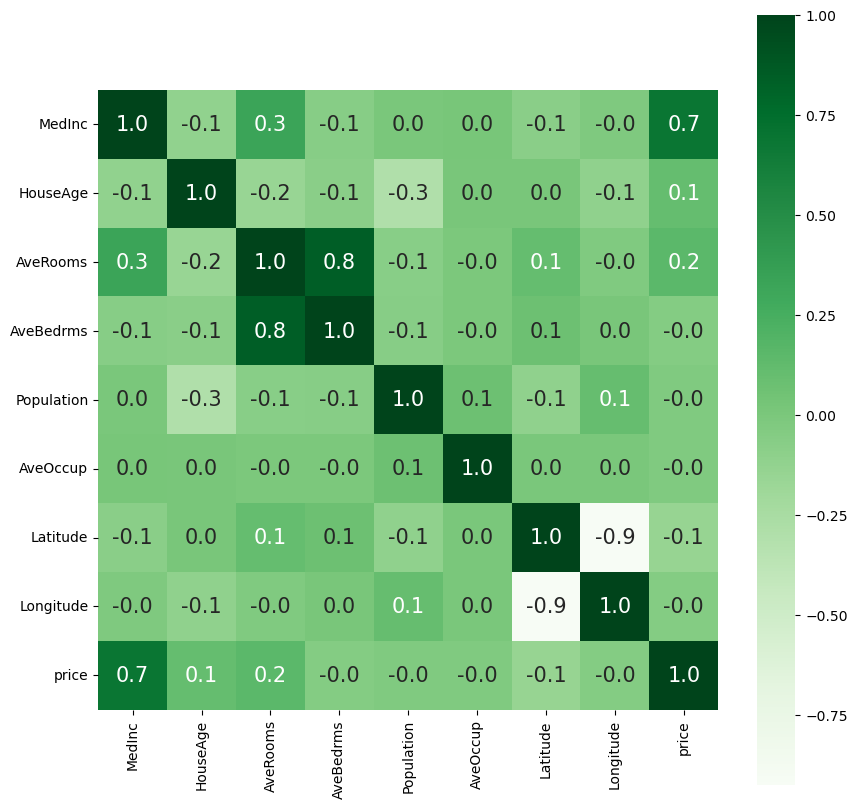

In [40]:
plt.figure(figsize=(10,10))
sns.heatmap(corr, cbar=True, square=True, fmt='.1f', cmap='Greens', annot=True, annot_kws={'size': 15})
plt.show()

<H1>SLR</H1>

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [55]:
X=df[['MedInc']]
y=df['price']

In [56]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [57]:
regression=LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [58]:
prediction=regression.predict(X_test)

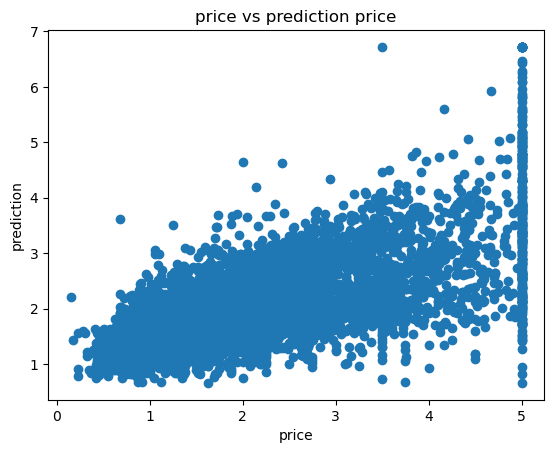

In [59]:
plt.scatter(y_test,prediction)
plt.xlabel("price")
plt.ylabel("prediction")
plt.title("price vs prediction price")
plt.show()

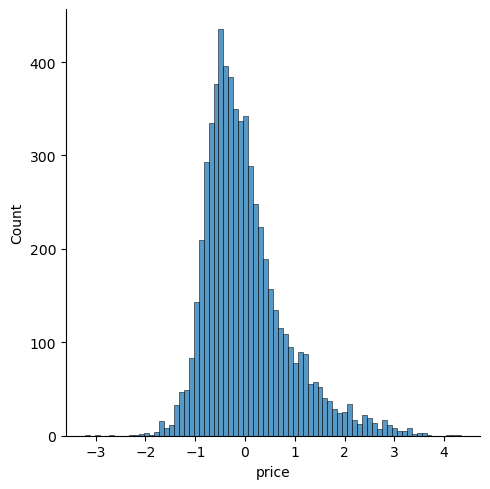

In [60]:
sns.displot(y_test-prediction)
plt.show()

In [61]:
from sklearn import metrics

print(metrics.r2_score(y_test,prediction))
print(metrics.mean_absolute_error(y_test,prediction))
print(metrics.mean_squared_error(y_test,prediction))
print(np.square(metrics.mean_squared_error(y_test,prediction)))

0.47293192589970245
0.6231559293823175
0.6917979868048499
0.47858445454724335
